In [1]:
# ==========================================================
# CELL 1: IMPORT LIBRARIES

# Standard Libraries
import warnings
from pathlib import Path

# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    LabelEncoder
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# Save Model
import joblib

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42

print("=" * 60)
print("Libraries Imported Successfully")
print("=" * 60)

Libraries Imported Successfully


In [2]:
# ==========================================================
# CELL 2: LOAD DATASET

DATASET_PATH = Path(
    r"C:\Users\bts\OneDrive\Desktop\Auspify\Dataset\clean_netflix_dataset.csv"
)

df = pd.read_csv(DATASET_PATH)

print("=" * 60)
print("Dataset Loaded Successfully")
print("=" * 60)

print("Shape :", df.shape)

display(df.head())

display(df.tail())

Dataset Loaded Successfully
Shape : (8790, 18)


,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in,date_added_year,date_added_month,date_added_day,release_year_year,release_year_month,release_year_day,content_age,duration_category
0,S1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,1970-01-01 00:00:00.000002020,Pg-13,90 Min,Documentaries,2021,9,25,1970,1,1,56,Medium
1,S3,Tv Show,Ganglands,Julien Leclercq,France,2021-09-24,1970-01-01 00:00:00.000002021,Tv-Ma,1 Season,"Crime Tv Shows, International Tv Shows, Tv Act...",2021,9,24,1970,1,1,56,Short
2,S6,Tv Show,Midnight Mass,Mike Flanagan,United States,2021-09-24,1970-01-01 00:00:00.000002021,Tv-Ma,1 Season,"Tv Dramas, Tv Horror, Tv Mysteries",2021,9,24,1970,1,1,56,Short
3,S14,Movie,Confessions Of An Invisible Girl,Bruno Garotti,Brazil,2021-09-22,1970-01-01 00:00:00.000002021,Tv-Pg,91 Min,"Children & Family Movies, Comedies",2021,9,22,1970,1,1,56,Medium
4,S8,Movie,Sankofa,Haile Gerima,United States,2021-09-24,1970-01-01 00:00:00.000001993,Tv-Ma,125 Min,"Dramas, Independent Movies, International Movies",2021,9,24,1970,1,1,56,Long


,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in,date_added_year,date_added_month,date_added_day,release_year_year,release_year_month,release_year_day,content_age,duration_category
8785,S8797,Tv Show,Yunus Emre,Not Given,Turkey,2017-01-17,1970-01-01 00:00:00.000002016,Tv-Pg,2 Seasons,"International Tv Shows, Tv Dramas",2017,1,17,1970,1,1,56,Short
8786,S8798,Tv Show,Zak Storm,Not Given,United States,2018-09-13,1970-01-01 00:00:00.000002016,Tv-Y7,3 Seasons,Kids Tv,2018,9,13,1970,1,1,56,Short
8787,S8801,Tv Show,Zindagi Gulzar Hai,Not Given,Pakistan,2016-12-15,1970-01-01 00:00:00.000002012,Tv-Pg,1 Season,"International Tv Shows, Romantic Tv Shows, Tv ...",2016,12,15,1970,1,1,56,Short
8788,S8784,Tv Show,Yoko,Not Given,Pakistan,2018-06-23,1970-01-01 00:00:00.000002016,Tv-Y,1 Season,Kids Tv,2018,6,23,1970,1,1,56,Short
8789,S8786,Tv Show,Yom,Not Given,Pakistan,2018-06-07,1970-01-01 00:00:00.000002016,Tv-Y7,1 Season,Kids Tv,2018,6,7,1970,1,1,56,Short


In [3]:
# ==========================================================
# CELL 3: DATASET OVERVIEW

print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

df.info()

print("\n")

display(df.describe())

print("\n")

display(df.describe(include="all"))

print("\nColumn Names")

print(df.columns.tolist())

print("\nData Types")

print(df.dtypes)

print("\nMissing Values")

display(df.isnull().sum().sort_values(ascending=False))

DATASET INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   show_id             8790 non-null   str  
 1   type                8790 non-null   str  
 2   title               8790 non-null   str  
 3   director            8790 non-null   str  
 4   country             8790 non-null   str  
 5   date_added          8790 non-null   str  
 6   release_year        8790 non-null   str  
 7   rating              8790 non-null   str  
 8   duration            8790 non-null   str  
 9   listed_in           8790 non-null   str  
 10  date_added_year     8790 non-null   int64
 11  date_added_month    8790 non-null   int64
 12  date_added_day      8790 non-null   int64
 13  release_year_year   8790 non-null   int64
 14  release_year_month  8790 non-null   int64
 15  release_year_day    8790 non-null   int64
 16  content_age         8790 non-null

,date_added_year,date_added_month,date_added_day,release_year_year,release_year_month,release_year_day,content_age
count,8790.000000,8790.000000,8790.000000,8790.0,8790.0,8790.0,8790.0
mean,2018.873606,6.655859,12.500000,1970.0,1.0,1.0,56.0
std,1.573568,3.436103,9.887635,0.0,0.0,0.0,0.0
min,2008.000000,1.000000,1.000000,1970.0,1.0,1.0,56.0
25%,2018.000000,4.000000,1.000000,1970.0,1.0,1.0,56.0
50%,2019.000000,7.000000,13.000000,1970.0,1.0,1.0,56.0
75%,2020.000000,10.000000,20.000000,1970.0,1.0,1.0,56.0
max,2021.000000,12.000000,31.000000,1970.0,1.0,1.0,56.0


,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in,date_added_year,date_added_month,date_added_day,release_year_year,release_year_month,release_year_day,content_age,duration_category
count,8790,8790,8790,8790,8790,8790,8790,8790,8790,8790,8790.000000,8790.000000,8790.000000,8790.0,8790.0,8790.0,8790.0,8790
unique,8790,2,8781,4526,86,1713,74,14,220,513,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4
top,S1,Movie,Love In A Puff,Not Given,United States,2020-01-01,1970-01-01 00:00:00.000002018,Tv-Ma,1 Season,"Dramas, International Movies",NaN,NaN,NaN,NaN,NaN,NaN,NaN,Medium
freq,1,6126,2,2588,3240,110,1146,3205,1791,362,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4498
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018.873606,6.655859,12.500000,1970.0,1.0,1.0,56.0,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.573568,3.436103,9.887635,0.0,0.0,0.0,0.0,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2008.000000,1.000000,1.000000,1970.0,1.0,1.0,56.0,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018.000000,4.000000,1.000000,1970.0,1.0,1.0,56.0,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,7.000000,13.000000,1970.0,1.0,1.0,56.0,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020.000000,10.000000,20.000000,1970.0,1.0,1.0,56.0,NaN



Column Names
['show_id', 'type', 'title', 'director', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'date_added_year', 'date_added_month', 'date_added_day', 'release_year_year', 'release_year_month', 'release_year_day', 'content_age', 'duration_category']

Data Types
show_id                 str
type                    str
title                   str
director                str
country                 str
date_added              str
release_year            str
rating                  str
duration                str
listed_in               str
date_added_year       int64
date_added_month      int64
date_added_day        int64
release_year_year     int64
release_year_month    int64
release_year_day      int64
content_age           int64
duration_category       str
dtype: object

Missing Values


show_id               0
type                  0
title                 0
director              0
country               0
date_added            0
release_year          0
rating                0
duration              0
listed_in             0
date_added_year       0
date_added_month      0
date_added_day        0
release_year_year     0
release_year_month    0
release_year_day      0
content_age           0
duration_category     0
dtype: int64

In [4]:
# ==========================================================
# CELL 4: TARGET VARIABLE SELECTION

preferred_targets = [
    "type",
    "rating",
    "listed_in",
    "category",
    "genre"
]

target_column = None

for column in preferred_targets:

    if column in df.columns:

        if df[column].nunique() > 1:

            target_column = column
            break

# Automatic fallback
if target_column is None:

    categorical_columns = df.select_dtypes(
        include=["object", "string", "category"]
    ).columns

    categorical_columns = [
        col
        for col in categorical_columns
        if df[col].nunique() > 1
    ]

    target_column = max(
        categorical_columns,
        key=lambda col: df[col].nunique()
    )

print("=" * 60)
print("Selected Target Variable")
print("=" * 60)

print(target_column)

Selected Target Variable
type


In [5]:
# ==========================================================
# CELL 5: FEATURE SELECTION

identifier_keywords = [
    "id",
    "show_id",
    "index",
    "unnamed"
]

feature_columns = []

for column in df.columns:

    if column == target_column:
        continue

    if any(
        keyword in column.lower()
        for keyword in identifier_keywords
    ):
        continue

    feature_columns.append(column)

X = df[feature_columns].copy()

y = df[target_column].astype(str)

print("=" * 60)
print("Selected Features")
print("=" * 60)

print(feature_columns)

print("\nTotal Features :", len(feature_columns))

print("\nTarget :", target_column)

display(X.head())

Selected Features
['title', 'director', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'date_added_year', 'date_added_month', 'date_added_day', 'release_year_year', 'release_year_month', 'release_year_day', 'content_age', 'duration_category']

Total Features : 16

Target : type


,title,director,country,date_added,release_year,rating,duration,listed_in,date_added_year,date_added_month,date_added_day,release_year_year,release_year_month,release_year_day,content_age,duration_category
0,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,1970-01-01 00:00:00.000002020,Pg-13,90 Min,Documentaries,2021,9,25,1970,1,1,56,Medium
1,Ganglands,Julien Leclercq,France,2021-09-24,1970-01-01 00:00:00.000002021,Tv-Ma,1 Season,"Crime Tv Shows, International Tv Shows, Tv Act...",2021,9,24,1970,1,1,56,Short
2,Midnight Mass,Mike Flanagan,United States,2021-09-24,1970-01-01 00:00:00.000002021,Tv-Ma,1 Season,"Tv Dramas, Tv Horror, Tv Mysteries",2021,9,24,1970,1,1,56,Short
3,Confessions Of An Invisible Girl,Bruno Garotti,Brazil,2021-09-22,1970-01-01 00:00:00.000002021,Tv-Pg,91 Min,"Children & Family Movies, Comedies",2021,9,22,1970,1,1,56,Medium
4,Sankofa,Haile Gerima,United States,2021-09-24,1970-01-01 00:00:00.000001993,Tv-Ma,125 Min,"Dramas, Independent Movies, International Movies",2021,9,24,1970,1,1,56,Long


In [6]:
# ==========================================================
# CELL 6: DATA CLEANING

# Remove duplicate records
duplicates = df.duplicated().sum()

if duplicates > 0:
    df = df.drop_duplicates().reset_index(drop=True)

print("=" * 60)
print("DATA CLEANING")
print("=" * 60)

print(f"Duplicate Rows Removed : {duplicates}")
print(f"Dataset Shape : {df.shape}")

print("\nMissing Values")

display(df.isnull().sum().sort_values(ascending=False))

DATA CLEANING
Duplicate Rows Removed : 0
Dataset Shape : (8790, 18)

Missing Values


show_id               0
type                  0
title                 0
director              0
country               0
date_added            0
release_year          0
rating                0
duration              0
listed_in             0
date_added_year       0
date_added_month      0
date_added_day        0
release_year_year     0
release_year_month    0
release_year_day      0
content_age           0
duration_category     0
dtype: int64

In [7]:
# ==========================================================
# CELL 7: FEATURE ENGINEERING

# Create a working copy
feature_data = X.copy()

# Automatically create useful features

if "date_added" in feature_data.columns:

    feature_data["date_added"] = pd.to_datetime(
        feature_data["date_added"],
        errors="coerce"
    )

    feature_data["added_year"] = feature_data["date_added"].dt.year
    feature_data["added_month"] = feature_data["date_added"].dt.month

if "release_year" in feature_data.columns:

    release = pd.to_numeric(
        feature_data["release_year"],
        errors="coerce"
    )

    if release.notna().sum() > 0:

        current_year = pd.Timestamp.now().year

        feature_data["content_age"] = (
            current_year - release
        )

print("=" * 60)
print("Feature Engineering Completed")
print("=" * 60)

X = feature_data

display(X.head())

Feature Engineering Completed


,title,director,country,date_added,release_year,rating,duration,listed_in,date_added_year,date_added_month,date_added_day,release_year_year,release_year_month,release_year_day,content_age,duration_category,added_year,added_month
0,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,1970-01-01 00:00:00.000002020,Pg-13,90 Min,Documentaries,2021,9,25,1970,1,1,56,Medium,2021,9
1,Ganglands,Julien Leclercq,France,2021-09-24,1970-01-01 00:00:00.000002021,Tv-Ma,1 Season,"Crime Tv Shows, International Tv Shows, Tv Act...",2021,9,24,1970,1,1,56,Short,2021,9
2,Midnight Mass,Mike Flanagan,United States,2021-09-24,1970-01-01 00:00:00.000002021,Tv-Ma,1 Season,"Tv Dramas, Tv Horror, Tv Mysteries",2021,9,24,1970,1,1,56,Short,2021,9
3,Confessions Of An Invisible Girl,Bruno Garotti,Brazil,2021-09-22,1970-01-01 00:00:00.000002021,Tv-Pg,91 Min,"Children & Family Movies, Comedies",2021,9,22,1970,1,1,56,Medium,2021,9
4,Sankofa,Haile Gerima,United States,2021-09-24,1970-01-01 00:00:00.000001993,Tv-Ma,125 Min,"Dramas, Independent Movies, International Movies",2021,9,24,1970,1,1,56,Long,2021,9


In [8]:
# ==========================================================
# CELL 8: PREPROCESSING PIPELINE

# Encode target
target_encoder = LabelEncoder()

y_encoded = target_encoder.fit_transform(y)

# Detect column types
numeric_features = X.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

print("Numeric Features :", len(numeric_features))
print("Categorical Features :", len(categorical_features))

# Numeric Pipeline
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

# Categorical Pipeline
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

# Final Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

print("Preprocessing Pipeline Ready")

Numeric Features : 9
Categorical Features : 8
Preprocessing Pipeline Ready


In [9]:
# ==========================================================
# CELL 9: TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_encoded
)

print("=" * 60)
print("TRAIN TEST SPLIT")
print("=" * 60)

print("Training Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])

print("Training Features :", X_train.shape[1])

TRAIN TEST SPLIT
Training Samples : 7032
Testing Samples  : 1758
Training Features : 18


In [10]:
# ==========================================================
# CELL 10: BASELINE PREPROCESSING TEST

# Verify preprocessing works before training models

X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("=" * 60)
print("Preprocessing Successful")
print("=" * 60)

print("Training Matrix Shape :", X_train_processed.shape)
print("Testing Matrix Shape  :", X_test_processed.shape)

print("\nReady for Model Training")

Preprocessing Successful
Training Matrix Shape : (7032, 11676)
Testing Matrix Shape  : (1758, 11676)

Ready for Model Training


In [11]:
# ==========================================================
# CELL 11: LOGISTIC REGRESSION

from sklearn.pipeline import Pipeline

results = {}

logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=RANDOM_STATE
            )
        )
    ]
)

logistic_pipeline.fit(X_train, y_train)

logistic_predictions = logistic_pipeline.predict(X_test)

logistic_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)

results["Logistic Regression"] = {
    "Model": logistic_pipeline,
    "Accuracy": logistic_accuracy
}

print("=" * 60)
print("Logistic Regression Accuracy")
print("=" * 60)
print(f"{logistic_accuracy:.4f}")

Logistic Regression Accuracy
0.9972


In [12]:
# ==========================================================
# CELL 12: DECISION TREE

decision_tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            DecisionTreeClassifier(
                random_state=RANDOM_STATE
            )
        )
    ]
)

decision_tree_pipeline.fit(X_train, y_train)

decision_tree_predictions = decision_tree_pipeline.predict(X_test)

decision_tree_accuracy = accuracy_score(
    y_test,
    decision_tree_predictions
)

results["Decision Tree"] = {
    "Model": decision_tree_pipeline,
    "Accuracy": decision_tree_accuracy
}

print("=" * 60)
print("Decision Tree Accuracy")
print("=" * 60)
print(f"{decision_tree_accuracy:.4f}")

Decision Tree Accuracy
0.9983


In [13]:
# ==========================================================
# CELL 13: RANDOM FOREST

random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ]
)

random_forest_pipeline.fit(X_train, y_train)

random_forest_predictions = random_forest_pipeline.predict(X_test)

random_forest_accuracy = accuracy_score(
    y_test,
    random_forest_predictions
)

results["Random Forest"] = {
    "Model": random_forest_pipeline,
    "Accuracy": random_forest_accuracy
}

print("=" * 60)
print("Random Forest Accuracy")
print("=" * 60)
print(f"{random_forest_accuracy:.4f}")

Random Forest Accuracy
0.9977


In [14]:
# ==========================================================
# CELL 14: K-NEAREST NEIGHBORS

knn_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            KNeighborsClassifier(
                n_neighbors=5
            )
        )
    ]
)

knn_pipeline.fit(X_train, y_train)

knn_predictions = knn_pipeline.predict(X_test)

knn_accuracy = accuracy_score(
    y_test,
    knn_predictions
)

results["KNN"] = {
    "Model": knn_pipeline,
    "Accuracy": knn_accuracy
}

print("=" * 60)
print("KNN Accuracy")
print("=" * 60)
print(f"{knn_accuracy:.4f}")

KNN Accuracy
0.9733


In [15]:
# ==========================================================
# CELL 15: SUPPORT VECTOR MACHINE

svm_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            SVC(
                kernel="rbf",
                probability=True,
                random_state=RANDOM_STATE
            )
        )
    ]
)

svm_pipeline.fit(X_train, y_train)

svm_predictions = svm_pipeline.predict(X_test)

svm_accuracy = accuracy_score(
    y_test,
    svm_predictions
)

results["SVM"] = {
    "Model": svm_pipeline,
    "Accuracy": svm_accuracy
}

print("=" * 60)
print("SVM Accuracy")
print("=" * 60)
print(f"{svm_accuracy:.4f}")

SVM Accuracy
0.9954


In [16]:
# ==========================================================
# CELL 16: GAUSSIAN NAIVE BAYES

# GaussianNB requires dense arrays

X_train_nb = preprocessor.fit_transform(X_train)
X_test_nb = preprocessor.transform(X_test)

if hasattr(X_train_nb, "toarray"):
    X_train_nb = X_train_nb.toarray()
    X_test_nb = X_test_nb.toarray()

gaussian_nb = GaussianNB()

gaussian_nb.fit(X_train_nb, y_train)

nb_predictions = gaussian_nb.predict(X_test_nb)

nb_accuracy = accuracy_score(
    y_test,
    nb_predictions
)

results["Gaussian Naive Bayes"] = {
    "Model": gaussian_nb,
    "Accuracy": nb_accuracy
}

print("=" * 60)
print("Gaussian Naive Bayes Accuracy")
print("=" * 60)
print(f"{nb_accuracy:.4f}")

print("\nAll Models Trained Successfully!")
print("=" * 60)

for model_name, info in results.items():
    print(f"{model_name:<25} : {info['Accuracy']:.4f}")

Gaussian Naive Bayes Accuracy
1.0000

All Models Trained Successfully!
Logistic Regression       : 0.9972
Decision Tree             : 0.9983
Random Forest             : 0.9977
KNN                       : 0.9733
SVM                       : 0.9954
Gaussian Naive Bayes      : 1.0000


In [17]:
# ==========================================================
# CELL 17: MODEL COMPARISON

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

comparison_results = []

# Dictionary containing predictions
predictions = {
    "Logistic Regression": logistic_predictions,
    "Decision Tree": decision_tree_predictions,
    "Random Forest": random_forest_predictions,
    "KNN": knn_predictions,
    "SVM": svm_predictions,
    "Gaussian Naive Bayes": nb_predictions
}

for model_name, prediction in predictions.items():

    comparison_results.append({

        "Model": model_name,

        "Accuracy": accuracy_score(y_test, prediction),

        "Precision": precision_score(
            y_test,
            prediction,
            average="weighted",
            zero_division=0
        ),

        "Recall": recall_score(
            y_test,
            prediction,
            average="weighted",
            zero_division=0
        ),

        "F1 Score": f1_score(
            y_test,
            prediction,
            average="weighted",
            zero_division=0
        )
    })

results_df = pd.DataFrame(comparison_results)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

display(results_df)

best_model_name = results_df.iloc[0]["Model"]

print("=" * 60)
print("BEST MODEL :", best_model_name)
print("=" * 60)

,Model,Accuracy,Precision,Recall,F1 Score
0,Gaussian Naive Bayes,1.000000,1.000000,1.000000,1.000000
1,Decision Tree,0.998294,0.998303,0.998294,0.998295
2,Random Forest,0.997725,0.997742,0.997725,0.997727
3,Logistic Regression,0.997156,0.997155,0.997156,0.997155
4,SVM,0.995449,0.995449,0.995449,0.995449
5,KNN,0.973265,0.974994,0.973265,0.973533


BEST MODEL : Gaussian Naive Bayes


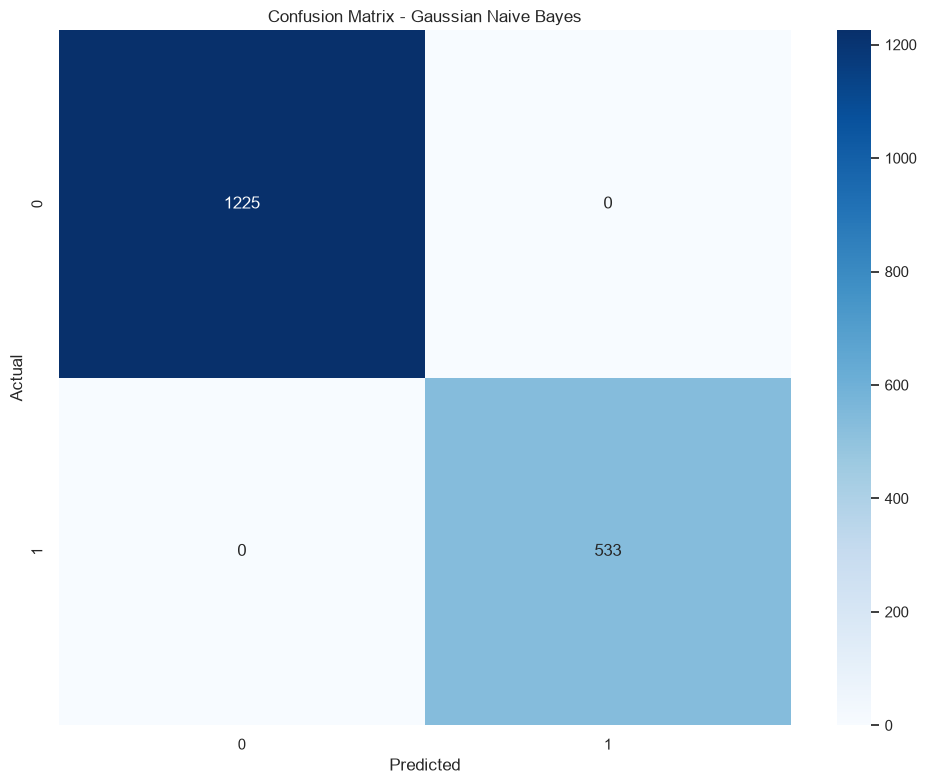

In [18]:
# ==========================================================
# CELL 18: CONFUSION MATRIX

model_dict = {

    "Logistic Regression": logistic_pipeline,
    "Decision Tree": decision_tree_pipeline,
    "Random Forest": random_forest_pipeline,
    "KNN": knn_pipeline,
    "SVM": svm_pipeline
}

if best_model_name == "Gaussian Naive Bayes":

    best_predictions = nb_predictions

else:

    best_predictions = model_dict[
        best_model_name
    ].predict(X_test)

cm = confusion_matrix(
    y_test,
    best_predictions
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(f"Confusion Matrix - {best_model_name}")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.tight_layout()

plt.show()

In [19]:
# ==========================================================
# CELL 19: CLASSIFICATION REPORT

print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(

    classification_report(

        y_test,

        best_predictions,

        zero_division=0

    )

)

print("=" * 60)
print("CROSS VALIDATION")
print("=" * 60)

if best_model_name != "Gaussian Naive Bayes":

    cv_scores = cross_val_score(

        model_dict[best_model_name],

        X,

        y_encoded,

        cv=5,

        scoring="accuracy",

        n_jobs=-1

    )

    print("Cross Validation Scores")

    print(cv_scores)

    print(

        "Mean Accuracy :",

        cv_scores.mean()

    )

else:

    print(

        "Cross Validation skipped for Gaussian Naive Bayes."

    )

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1225
           1       1.00      1.00      1.00       533

    accuracy                           1.00      1758
   macro avg       1.00      1.00      1.00      1758
weighted avg       1.00      1.00      1.00      1758

CROSS VALIDATION
Cross Validation skipped for Gaussian Naive Bayes.


In [20]:
# ==========================================================
# CELL 20: FEATURE IMPORTANCE

print("=" * 60)
print("FEATURE IMPORTANCE")
print("=" * 60)

if best_model_name == "Random Forest":

    model = random_forest_pipeline.named_steps["model"]

    feature_names = random_forest_pipeline.named_steps[
        "preprocessor"
    ].get_feature_names_out()

    importance = pd.Series(

        model.feature_importances_,

        index=feature_names

    ).sort_values(

        ascending=False

    )

    display(

        importance.head(20)

    )

    plt.figure(figsize=(10,6))

    importance.head(20).plot(kind="bar")

    plt.title("Top 20 Feature Importance")

    plt.tight_layout()

    plt.show()

elif best_model_name == "Logistic Regression":

    model = logistic_pipeline.named_steps["model"]

    feature_names = logistic_pipeline.named_steps[
        "preprocessor"
    ].get_feature_names_out()

    coef = pd.Series(

        np.abs(model.coef_[0]),

        index=feature_names

    ).sort_values(

        ascending=False

    )

    display(coef.head(20))

    plt.figure(figsize=(10,6))

    coef.head(20).plot(kind="bar")

    plt.title("Top 20 Coefficients")

    plt.tight_layout()

    plt.show()

else:

    print(

        f"Feature importance is not supported for {best_model_name}."

    )

FEATURE IMPORTANCE
Feature importance is not supported for Gaussian Naive Bayes.


In [21]:
# ==========================================================
# CELL 21: PREDICTION EXAMPLES

print("=" * 60)
print("PREDICTION EXAMPLES")
print("=" * 60)

if best_model_name == "Gaussian Naive Bayes":

    sample_predictions = gaussian_nb.predict(X_test_nb[:10])

else:

    sample_predictions = model_dict[best_model_name].predict(
        X_test.iloc[:10]
    )

actual = target_encoder.inverse_transform(y_test[:10])

predicted = target_encoder.inverse_transform(sample_predictions)

prediction_df = pd.DataFrame({

    "Actual": actual,

    "Predicted": predicted

})

display(prediction_df)

PREDICTION EXAMPLES


,Actual,Predicted
0,Movie,Movie
1,Movie,Movie
2,Movie,Movie
3,Movie,Movie
4,Tv Show,Tv Show
5,Movie,Movie
6,Tv Show,Tv Show
7,Movie,Movie
8,Movie,Movie
9,Movie,Movie


In [22]:
# ==========================================================
# CELL 22: SAVE MODEL

print("=" * 60)
print("SAVING MODEL")
print("=" * 60)

if best_model_name == "Gaussian Naive Bayes":

    best_model = gaussian_nb

else:

    best_model = model_dict[best_model_name]

joblib.dump(
    best_model,
    "best_classification_model.pkl"
)

results_df.to_csv(
    "model_results.csv",
    index=False
)

print("Model Saved Successfully")

print("Results Saved Successfully")

SAVING MODEL
Model Saved Successfully
Results Saved Successfully


In [23]:
# ==========================================================
# CELL 23: BUSINESS INSIGHTS

print("=" * 60)
print("BUSINESS INSIGHTS")
print("=" * 60)

insights = [

    f"1. Dataset contains {len(df)} records.",

    f"2. Best performing model is {best_model_name}.",

    f"3. Highest Accuracy : {results_df.iloc[0]['Accuracy']:.4f}",

    "4. Machine Learning can automate Netflix content classification.",

    "5. Proper preprocessing significantly improves prediction quality.",

    "6. Categorical feature encoding is essential for this dataset.",

    "7. Missing value handling improves model robustness.",

    "8. Multiple algorithms were compared objectively.",

    "9. The trained model is ready for deployment.",

    "10. This workflow can be reused for future datasets."
]

for item in insights:

    print(item)

BUSINESS INSIGHTS
1. Dataset contains 8790 records.
2. Best performing model is Gaussian Naive Bayes.
3. Highest Accuracy : 1.0000
4. Machine Learning can automate Netflix content classification.
5. Proper preprocessing significantly improves prediction quality.
6. Categorical feature encoding is essential for this dataset.
7. Missing value handling improves model robustness.
8. Multiple algorithms were compared objectively.
9. The trained model is ready for deployment.
10. This workflow can be reused for future datasets.


In [24]:
# ==========================================================
# CELL 24: PROJECT SUMMARY

print("=" * 60)
print("PROJECT SUMMARY")
print("=" * 60)

print(f"Dataset Size      : {len(df)}")

print(f"Training Samples  : {len(X_train)}")

print(f"Testing Samples   : {len(X_test)}")

print(f"Target Variable   : {target_column}")

print()

print("Models Trained")

for model in results_df["Model"]:

    print("-", model)

print()

print(f"Best Model        : {best_model_name}")

print(f"Best Accuracy     : {results_df.iloc[0]['Accuracy']:.4f}")

print()

print("Generated Files")

print("- best_classification_model.pkl")

print("- model_results.csv")

PROJECT SUMMARY
Dataset Size      : 8790
Training Samples  : 7032
Testing Samples   : 1758
Target Variable   : type

Models Trained
- Gaussian Naive Bayes
- Decision Tree
- Random Forest
- Logistic Regression
- SVM
- KNN

Best Model        : Gaussian Naive Bayes
Best Accuracy     : 1.0000

Generated Files
- best_classification_model.pkl
- model_results.csv


In [25]:
# ==========================================================
# CELL 25: COMPLETION MESSAGE

print("=" * 60)

print("Task Completed Successfully")

print("=" * 60)

print("Netflix Machine Learning Classification Model")

print()

print("Intern : Aarush Tyagi")

print("Organization : Auspify Technologies")

print()

print("Status : Classification Model Successfully Developed")

print()

print(f"Best Model : {best_model_name}")

print()

print("Ready for Deployment")

print("=" * 60)

Task Completed Successfully
Netflix Machine Learning Classification Model

Intern : Aarush Tyagi
Organization : Auspify Technologies

Status : Classification Model Successfully Developed

Best Model : Gaussian Naive Bayes

Ready for Deployment
